In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input   # ✅ CHANGE
from tensorflow.keras.applications import DenseNet121                 # ✅ CHANGE
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

ValueError: mount failed

In [ ]:
train_dir = "/content/drive/MyDrive/UG_Research/Gauri_Project/Dataset_Train_Test/Training"
test_dir  = "/content/drive/MyDrive/UG_Research/Gauri_Project/Dataset_Train_Test/Testing"

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Test samples:", test_gen.samples)

Found 5600 images belonging to 4 classes.
Found 1599 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train samples: 5600
Test samples: 1599


In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_dn = Model(inputs=base_model.input, outputs=outputs)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_dn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

history_dn = model_dn.fit(
    train_gen,
    validation_data=test_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 2248s 6s/step - accuracy: 0.7264 - loss: 0.7068 - val_accuracy: 0.7999 - val_loss: 0.5597 - learning_rate: 1.0000e-04
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 106s 302ms/step - accuracy: 0.8445 - loss: 0.4232 - val_accuracy: 0.8211 - val_loss: 0.5194 - learning_rate: 1.0000e-04
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 293ms/step - accuracy: 0.8700 - loss: 0.3547 - val_accuracy: 0.8412 - val_loss: 0.4920 - learning_rate: 1.0000e-04
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 104s 297ms/step - accuracy: 0.8866 - loss: 0.3081 - val_accuracy: 0.8537 - val_loss: 0.4616 - learning_rate: 1.0000e-04
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 104s 295ms/step - accuracy: 0.9007 - loss: 0.2780 - val_accuracy: 0.8630 - val_loss: 0.4486 - learning_rate: 1.0000e-04
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 292ms/step - accuracy: 0.9052 - loss: 0.2593 - val_accuracy: 0.8680 - val_loss: 0.4332 - learning_rate: 1.0000e-04
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 10

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_dn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dn_ft = model_dn.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 156s 354ms/step - accuracy: 0.9355 - loss: 0.1712 - val_accuracy: 0.9074 - val_loss: 0.3713 - learning_rate: 3.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 104s 298ms/step - accuracy: 0.9409 - loss: 0.1601 - val_accuracy: 0.9049 - val_loss: 0.3948 - learning_rate: 3.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 292ms/step - accuracy: 0.9491 - loss: 0.1443 - val_accuracy: 0.9131 - val_loss: 0.3777 - learning_rate: 3.0000e-05
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 295ms/step - accuracy: 0.9514 - loss: 0.1368 - val_accuracy: 0.9181 - val_loss: 0.3708 - learning_rate: 3.0000e-05
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 295ms/step - accuracy: 0.9543 - loss: 0.1289 - val_accuracy: 0.9193 - val_loss: 0.3691 - learning_rate: 3.0000e-05
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 104s 298ms/step - accuracy: 0.9620 - loss: 0.1146 - val_accuracy: 0.9231 - val_loss: 0.3600 - learning_rate: 3.0000e-05
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model_dn.evaluate(test_gen)

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9287 - loss: 0.3539


[0.3538607358932495, 0.9287054538726807]

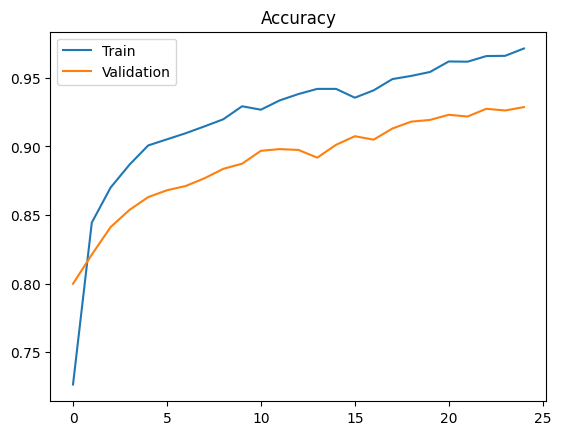

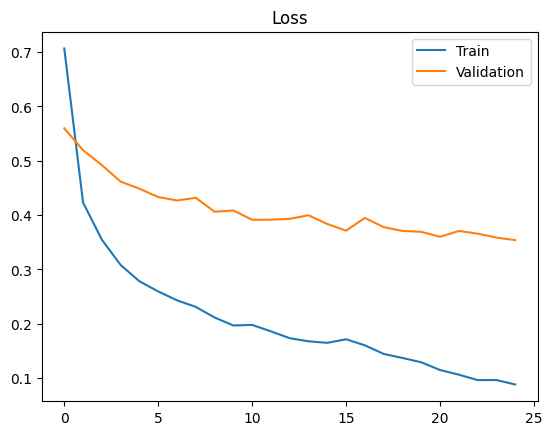

In [ ]:
plt.plot(history_dn.history['accuracy'] + history_dn_ft.history['accuracy'])
plt.plot(history_dn.history['val_accuracy'] + history_dn_ft.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()

plt.plot(history_dn.history['loss'] + history_dn_ft.history['loss'])
plt.plot(history_dn.history['val_loss'] + history_dn_ft.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss")
plt.show()

In [ ]:
y_true = test_gen.classes
y_pred = np.argmax(model_dn.predict(test_gen), axis=1)

print(classification_report(y_true, y_pred))

100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 215ms/step
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       400
           1       0.88      0.92      0.90       399
           2       0.93      1.00      0.96       400
           3       0.97      0.99      0.98       400

    accuracy                           0.93      1599
   macro avg       0.93      0.93      0.93      1599
weighted avg       0.93      0.93      0.93      1599



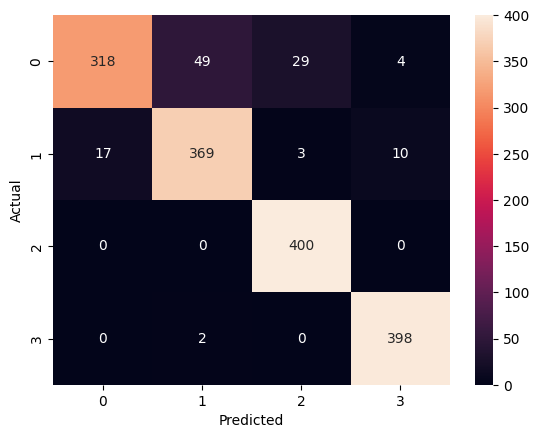

In [ ]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step


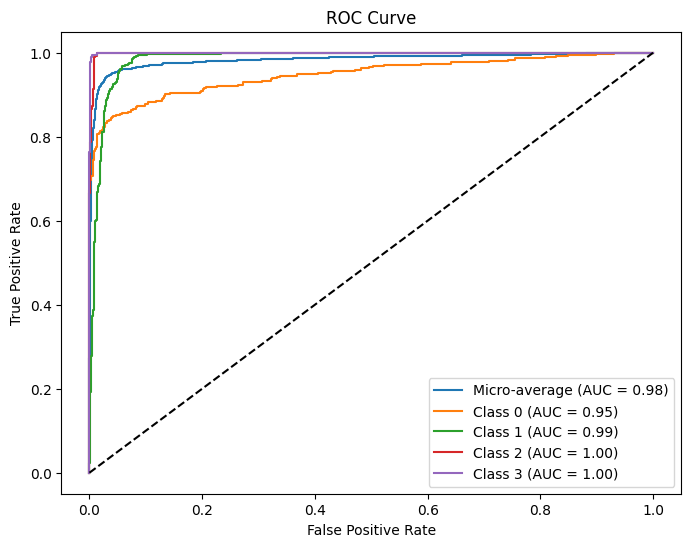

Class 0 AUC: 0.9476
Class 1 AUC: 0.9852
Class 2 AUC: 0.9986
Class 3 AUC: 0.9997
Micro-average AUC: 0.9837


In [ ]:
y_true = test_gen.classes
y_pred_probs = model_dn.predict(test_gen)

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    y_pred_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})")

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.4f}")

print(f"Micro-average AUC: {roc_auc['micro']:.4f}")

Model save files moved to 'Shared Folder' --> "/content/drive/MyDrive/UG_Research/Gauri_Project/model_files"

In [ ]:
model_dn.save('/content/drive/MyDrive/UG-Research/DenseNet121_modeld.h5')


In [ ]:
model_dn.save('/content/drive/MyDrive/UG-Research/Densenet121d.keras')